# Bibliotecas Pessoais e de Terceiros

In [1]:
from LIBS_PESSOAL.GustavoReconstrutorDeFalhas import ReconstrutorUsinaSolar
from LIBS_PESSOAL.GustavoAplicaMetodoDeWelchPLOT import MetodoDeWelch
from LIBS_PESSOAL.GustavoFeatureEngineering import FeatureEngineering
from LIBS_PESSOAL.GustavoBuracosDiurnosPLOT import Analisador_De_Buracos_Diurno
from LIBS_PESSOAL.GustavoPotenciasZeradasPLOT import Analisador_De_Potencia_Zero_Com_Sol_Presente
import pvlib
from pvlib.location import Location
from pvlib.irradiance import aoi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import signal
from IPython.display import display, Markdown

## Leitura E Transformação Dos Dados

In [2]:
path_date = './DADOS/Dados eficiência da Usina Petrolina.parquet'
df_full = pd.read_parquet(path_date, columns=['Time', 'Potência AC total (kW)', 'POA (W/m²)'])
df_full.rename(columns={'Potência AC total (kW)':'P', 'POA (W/m²)':'G'}, inplace=True)
st = df_full.set_index('Time')
st = st.sort_index(ascending=True)

PreencherNoites = FeatureEngineering()
st = PreencherNoites.preencher_noites_fisica(st_entrada=st, lat=-9.398611, lon=-40.50, angulo=88, angulo_painel = 15, fuso_horario='America/Recife')
ReconstrutorSolar = ReconstrutorUsinaSolar(area_hectares=1.48, limite_minutos=60, janela_vizinhos=10, col_p='P', col_g='G')
st = ReconstrutorSolar.reconstruir_via_analitico(st)
st = ReconstrutorSolar.reconstruir_via_euler(st)
st = ReconstrutorSolar.reconstruir_via_integral_midpoint(st)

## Análise Espectral de Potência Nos Dados Brutos e Pós Correção Na Potência Para Falhas $\le$ 60 Minutos

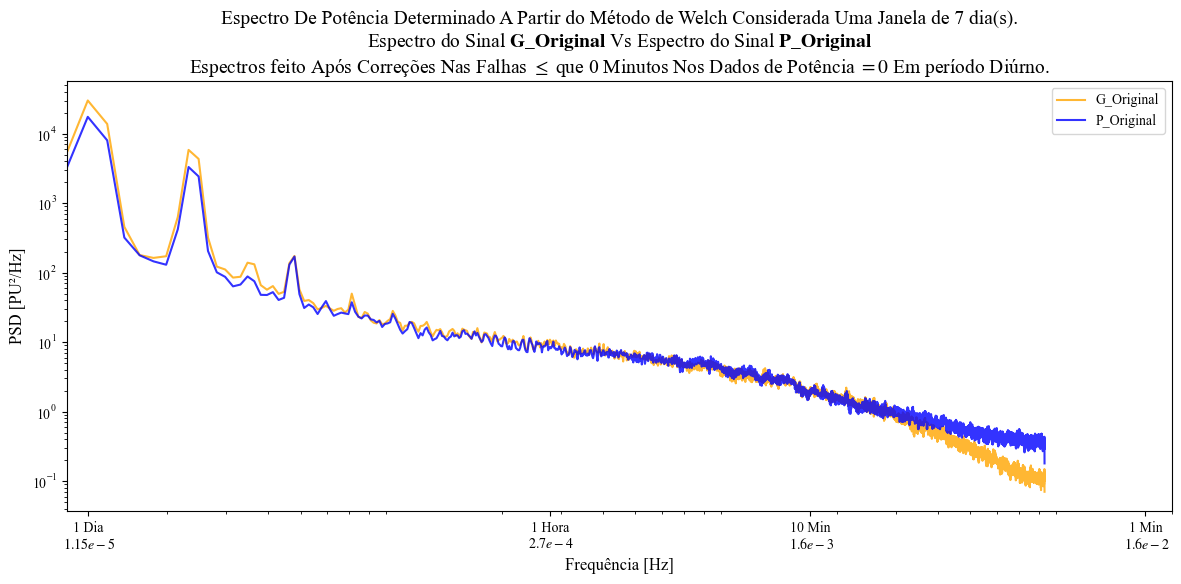

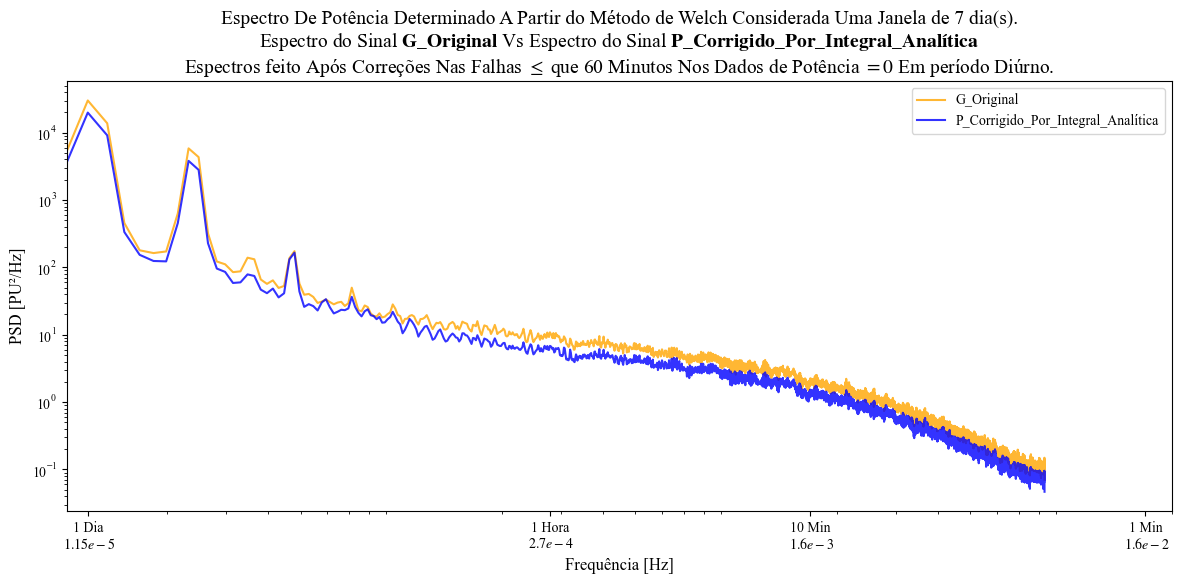

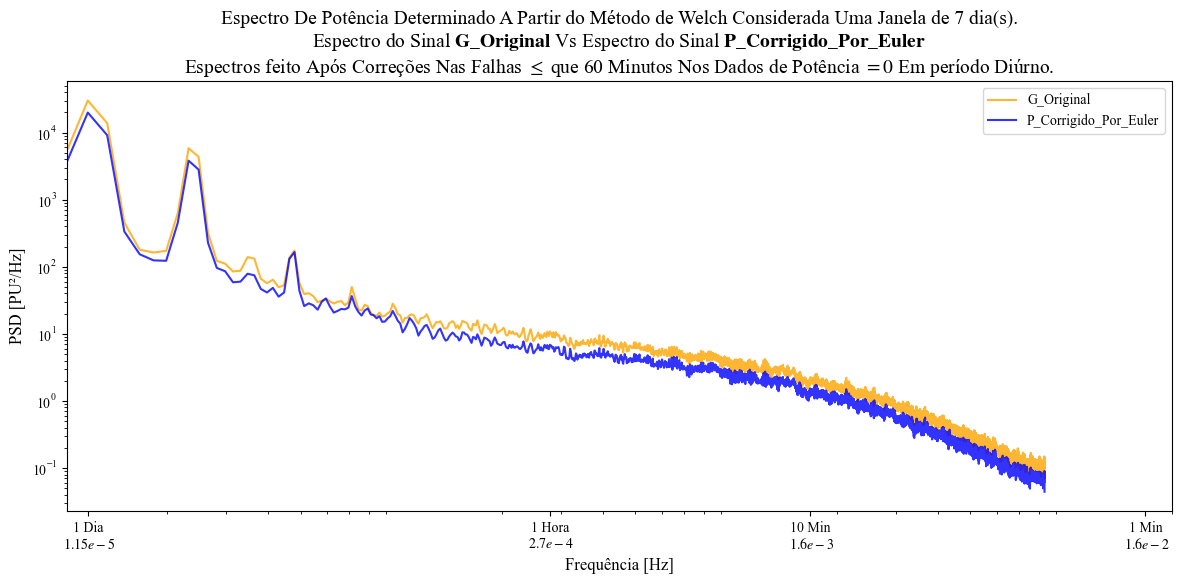

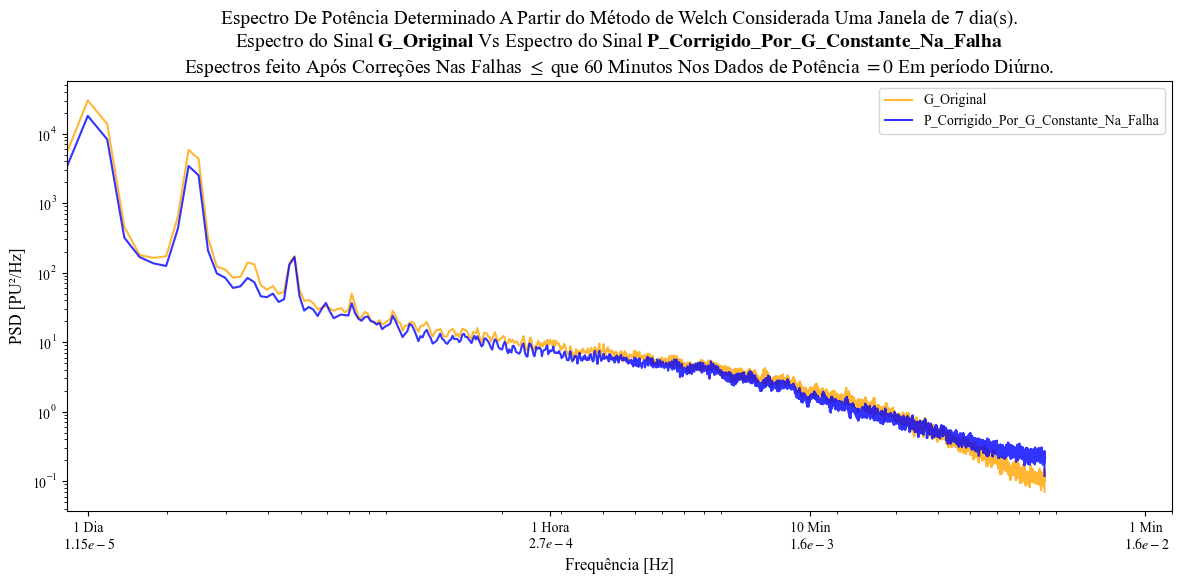

In [3]:
st_ = st[st['P']>=0].dropna()
welch=MetodoDeWelch()
for item in st_.columns:
    if (item == 'G') | (item == 'Zenith'):
        pass
    elif item=='P':
        welch.AplicaMetodoDeWelch(df=st_.loc['2019'], coluna_potencia=item, coluna_iradiancia='G',
                              win_size=7*1440, NOME_COLUNA_DE_POTENCIA_PARA_PLOT='P_Original', 
                              NOME_COLUNA_DE_IRRADIANCIA_PARA_PLOT='G_Original', minuto_correção='0')
    else:
        welch.AplicaMetodoDeWelch(df=st_.loc['2019'], coluna_potencia=item, coluna_iradiancia='G',
                              win_size=7*1440, NOME_COLUNA_DE_POTENCIA_PARA_PLOT=item, 
                              NOME_COLUNA_DE_IRRADIANCIA_PARA_PLOT='G_Original', minuto_correção='60')

# Considerando a Usina Como Um Filtro _Low-Pass_ Para correção de Falhas curtas e cutissimas `Igual ou Inferior a 60 Min.` 

Marcos et al. mostra que:


$$ \large H(s) = \frac{P(s)}{G(s)} = \frac{K}{\tau s + 1}$$

Onde:

* $P(s)$ é a saída (Potência).

* $G(s)$ é a entrada (Irradiação).

* $\tau$ é a constante de tempo baseada na área da usina em hectares ($\large \frac{\sqrt{S}}{2\pi \cdot 0.021}$).

## Manipulando $H(s)$ para aplicar a inversa de Laplace:

$$\large P(s) \cdot (\tau s + 1) = K \cdot G(s)$$

$$\large P(s) \cdot \tau s + P(s) = K \cdot G(s)$$

Aplicando ($\mathcal{L}^{-1}$), fica: 

$$\large h(t) = \mathcal{L}^{-1} \{H(s)\}$$

Então:

$$\large \tau \frac{dP(t)}{dt} + P(t) = K \cdot G(t)$$

Discretizando a derivada temporal via método de Euler (Retanglar Para frente - Backfoward):

$$\large \frac{dP(t)}{dt} \approx \frac{P[t] - P[t-1]}{\Delta t}$$

Onde:

* $\Delta t$ é o seu tempo de amostragem

Substituindo fica:

$$\large \tau \left( \frac{P[t] - P[t-1]}{\Delta t} \right) + P[t] = K \cdot G[t]$$

Isolando $\large P[t]$

$$\large \tau (P[t] - P[t-1]) + P[t] \Delta t = K G[t] \Delta t$$


$$\large P[t](\tau + \Delta t) = K G[t] \Delta t + \tau P[t-1]$$


$$\large P[t] = \left( \frac{\Delta t}{\tau + \Delta t} \right) K G[t] + \left( \frac{\tau}{\tau + \Delta t} \right) P[t-1]$$

Para simplificar a expressão, podems assumir que:

$$\large \alpha = \frac{\Delta t}{\tau + \Delta t}$$

$$\large 1 - \alpha = 1 - \left( \frac{\Delta t}{\tau + \Delta t} \right)$$

$$\large 1 - \alpha = \frac{\tau + \Delta t - \Delta t}{\tau + \Delta t}$$

$$\large 1 - \alpha = \frac{\tau}{\tau + \Delta t}$$

Então, substituindo na equação fica:

$$\large P[t] = \alpha \cdot (K \cdot G[t]) + (1 - \alpha) \cdot P[t-1]$$


## Anáise:

$$P[t] = \underbrace{\alpha}_{\text{Peso do Novo}} \cdot (\text{Entrada Atual}) + \underbrace{(1 - \alpha)}_{\text{Peso do Velho}} \cdot (\text{Histórico})$$

* $\large \alpha$: representa a contribuição do dado novo para a saída. 

* $(\large 1 - \alpha)$: Representa a contribuição da inércia (do estado anterior do sistema). Como a soma dos pesos é sempre $1$ ($\alpha + (1-\alpha) = 1$), isso garante que o filtro nunca vai criar ou destruir energia artificialmente, apenas balancear.

## Calculando $\alpha$:

* Área da Usina $(\large S)$: $\large 1,48$ hectares (calculado a partir dos 7.600 módulos).
* Tempo de Amostragem ($\large \Delta t$ ou $T_s$): $60$ segundos.

**1. Cálculo da Frequência de Corte ($\large f_c$)**

A equação empírica nos dá $\large f_c$ em Hz:

$$\large f_c = 0.021 \cdot S^{-0.5}$$

$$\large f_c = \frac{0,021}{\sqrt{S}}$$$$f_c = \frac{0,021}{\sqrt{1,48}}$$$$f_c \approx \frac{0,021}{1,21655}$$$$f_c \approx 0,01726 \, \text{Hz}$$

2. Determianando a Constante de Tempo $\large \tau$

$$\large \tau \triangleq \frac{1}{2\pi f_c}$$

A constante de tempo tau ($\tau$) é o inverso da frequência angular ($2\pi f_c$):

$$\tau = \frac{1}{2 \cdot 3,14 \cdot 0,01726}$$

$$\tau = \frac{1}{0,1084}$$$$\tau \approx 9,225 \, \text{segundos}$$

Isso significa que a usina leva cerca de 9,2 segundos para "sentir" plenamente o efeito de uma variação brusca de irradiância devido à sua inércia espacial.

Portanto $\alpha$ fica:

$$\large\alpha = \frac{\Delta t}{\tau + \Delta t}$$$$\large\alpha = \frac{60}{9,225 + 60}$$$$\large\alpha = \frac{60}{69,225}$$$$\large\mathbf{\alpha \approx 0,8667}$$

Isso significa que, a cada minuto, o valor da potência é composto por:

* 86,6% da irradiação que está chegando agora ($\alpha$).

* 13,4% da potência que já estava lá no minuto anterior ($1 - \alpha$).

Isso faz sentido físico: como a amostragem é lenta (1 min) e a usina é rápida (~9s), o "novo dado" tem muito mais peso que a "memória" do sistema.

## Plot do Gráfico de Flutuação de Irradiancia

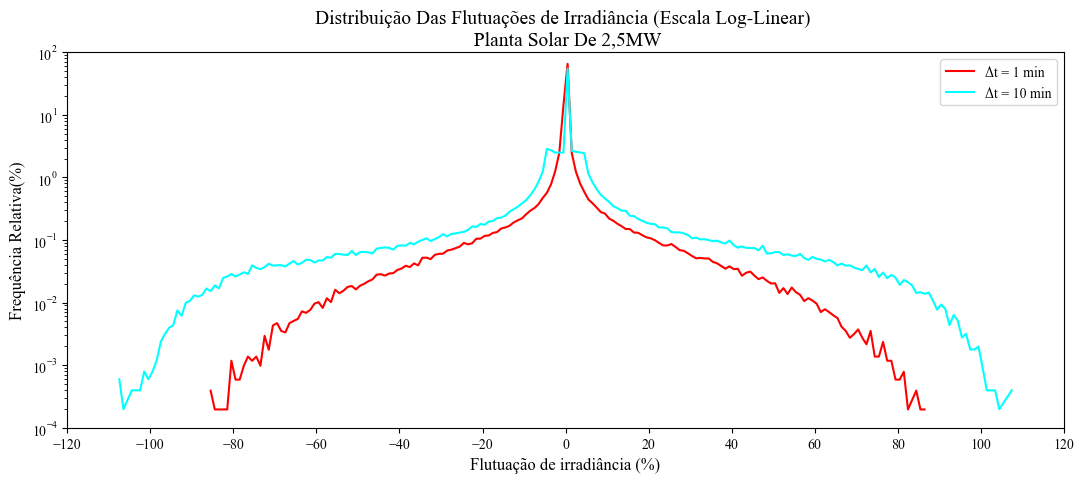

In [8]:
config_visual = {
    'figure.figsize': (11, 5),
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'mathtext.fontset': 'stix'}

with plt.rc_context(config_visual):
    deltas = [1, 10] # Delta t = 1 min e Delta t = 10 min
    cores = ['red', 'cyan']
    irradiacao_de_referencia = 1000
    for delta_t, cor in zip(deltas, cores):
        # O método .diff do Pandas: .diff(periods=k) faz G(t) - G(t-k)
        # A fórmula do artigo: (Diferença / 1000) * 100
        fluctuation_G = (st['G'].diff(periods=delta_t) / irradiacao_de_referencia) * 100
        # Remover o NaN gerados pelo .diff
        fluctuation_G = fluctuation_G.dropna()
        # CRIAÇÃO DO HISTOGRAMA (Bins de 1%)
        # faixas de -120% a +120% com passo de 1%
        bins = np.arange(-120, 121, 1) 
        # np.histogram conta quantos eventos caem em cada faixa
        counts, bin_edges = np.histogram(fluctuation_G, bins=bins)
        # Calcular o centro de cada bin para plotar a linha
        bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
        # NORMALIZAÇÃO (O Eixo Y)
        # Frequência Relativa (%) = (Contagem / Total) * 100
        rel_freq = (counts / len(fluctuation_G)) * 100
        # PLOTAGEM (Escala Log-Linear)
        # Filtra valores com frequencia 0 para não quebrar o log
        mask = rel_freq > 0
        plt.plot(bin_centers[mask], rel_freq[mask], 
                 label=f'Δt = {delta_t} min', 
                 color=cor, linewidth=1.5)
    plt.yscale('log')
    plt.xlabel('Flutuação de irradiância (%)')
    plt.ylabel('Frequência Relativa(%)')
    plt.title('Distribuição Das Flutuações de Irradiância (Escala Log-Linear) \n Planta Solar De 2,5MW')
    plt.legend()
    plt.ylim(10**-4, 100)
    plt.xlim(-120, 120)
    plt.xticks([-120, -100, -80, -60, -40, -20, 0, 20, 40, 60, 80, 100, 120])
    plt.tight_layout()
    plt.savefig('./GRAFICOS/DADO_TRATADO_distribuicao_da_irradiancia.png', format='png', dpi=2*600, bbox_inches='tight')
    plt.show()
    plt.close()

## Plot do Gráfico de Futuação de Potencia

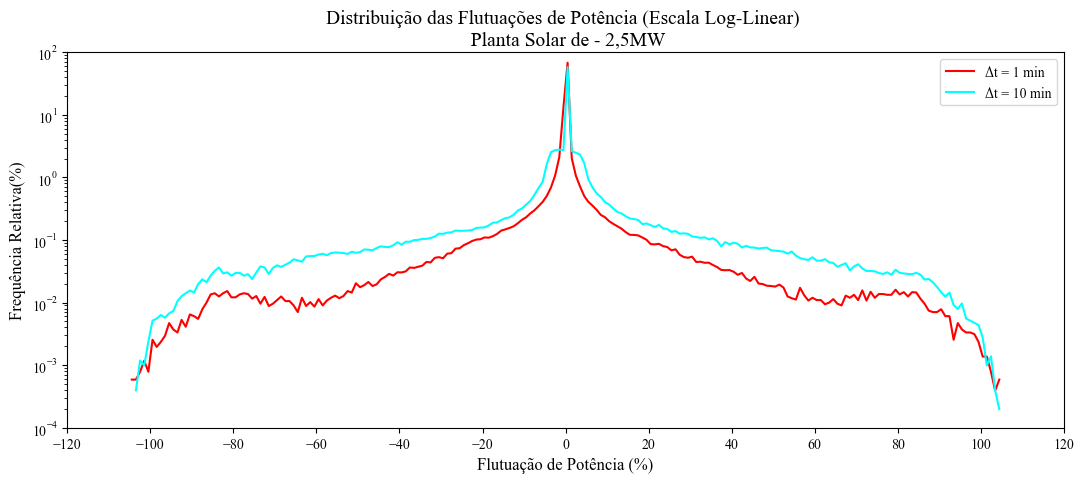

In [7]:
config_visual = {
    'figure.figsize': (11, 5),
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'mathtext.fontset': 'stix'}

with plt.rc_context(config_visual):
    
    deltas = [1, 10] # Delta t = 1 min e Delta t = 10 min
    cores = ['red', 'cyan'] # Cores iguais ao artigo para 60s e 600s
    potecia_de_referencia = 2500
    for delta_t, cor in zip(deltas, cores):
        # O método .diff do Pandas: .diff(periods=k) faz G(t) - G(t-k)
        # A fórmula do artigo: (Diferença / 1000) * 100
        fluctuation_P = (st['P'].diff(periods=delta_t) / potecia_de_referencia) * 100
        # Remover o NaN gerados pelo .diff
        fluctuation_P = fluctuation_P.dropna()
        # 2. CRIAÇÃO DO HISTOGRAMA (Bins de 1%)    
        # faixas de -120% a +120% com passo de 1%
        bins = np.arange(-120, 121, 1) 
        # np.histogram conta quantos eventos caem em cada faixa
        counts, bin_edges = np.histogram(fluctuation_P, bins=bins)
        # Calcular o centro de cada bin para plotar a linha
        bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
        # NORMALIZAÇÃO (O Eixo Y)
        # Frequência Relativa (%) = (Contagem / Total) * 100
        rel_freq = (counts / len(fluctuation_P)) * 100
        # PLOTAGEM (Escala Log-Linear)
        # Filtra valores com frequencia 0 para não quebrar o log
        mask = rel_freq > 0
        plt.plot(bin_centers[mask], rel_freq[mask], 
                 label=f'Δt = {delta_t} min', 
                 color=cor, linewidth=1.5)
    plt.yscale('log')
    plt.xlabel('Flutuação de Potência (%)')
    plt.ylabel('Frequência Relativa(%)')
    plt.title('Distribuição das Flutuações de Potência (Escala Log-Linear) \n Planta Solar de 2,5MW')
    plt.legend()
    plt.ylim(10**-4, 100) # Ajuste similar ao artigo
    plt.xlim(-120, 120)
    plt.xticks([-120, -100, -80, -60, -40, -20, 0, 20, 40, 60, 80, 100, 120])
    plt.tight_layout()
    plt.savefig('./GRAFICOS/DADO_TRATADO_distribuicao_da_potencia.png', format='png', dpi=2*600, bbox_inches='tight')
    plt.show()
    plt.close()